# Deep Reinforcement Learning — Lab Assignment 1
## Part 2: Autonomous Drone Rescue Using Dynamic Programming

**Course:** Deep Reinforcement Learning (BITS Pilani WILP)

---

**Student Name:** `<YOUR NAME>`  
**Student ID:** `<YOUR ID>`  
**Team Number:** 165  

---

### Execution Environment Info

In [3]:
import datetime
import socket
import platform
import os

exec_timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_hostname = socket.gethostname()
os_info = platform.platform()
py_version = platform.python_version()
user_name = os.getenv('USER', os.getenv('USERNAME', 'unknown'))

print('=' * 60)
print('EXECUTION ENVIRONMENT DETAILS')
print('=' * 60)
print(f'Timestamp       : {exec_timestamp}')
print(f'Hostname / VM ID: {vm_hostname}')
print(f'OS Platform     : {os_info}')
print(f'Python Version  : {py_version}')
print(f'Login User      : {user_name}')
print('=' * 60)

EXECUTION ENVIRONMENT DETAILS
Timestamp       : 2026-05-30 11:25:41
Hostname / VM ID: HPE-5CG54225XX
OS Platform     : Windows-11-10.0.26100-SP0
Python Version  : 3.14.5
Login User      : manjusub


---
## Imports

In [4]:
import numpy as np
import random
import math
import time
import copy
from itertools import product
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

print('All imports loaded.')

All imports loaded.


---
## Configuration — Group-Dependent Environment Setup

Group ID last digit = **5** → 6×6 grid, battery = 15, wind = 30%.  

| Parameter | Value |
|---|---|
| Grid size | 6 × 6 |
| Rescue targets | 3 |
| Charging stations | 2 |
| Danger zones | 4 |
| Blocked cells | 3 |
| Max battery | 15 |
| Wind probability | 30% |
| Max steps | 75 |

In [5]:
# ========================================================
# ENVIRONMENT CONFIGURATION — derived from group ID ending
# Change GROUP_LAST_DIGIT if your group is different
# ========================================================
GROUP_LAST_DIGIT = 5

# Grid dimensions
if GROUP_LAST_DIGIT <= 4:
    GRID_ROWS, GRID_COLS = 5, 5
    NUM_RESCUE = 2
    NUM_CHARGING = 1
    NUM_DANGER = 3
    NUM_BLOCKED = 2
    WIND_PROB = 0.20
    MAX_STEPS = 50
else:
    GRID_ROWS, GRID_COLS = 6, 6
    NUM_RESCUE = 3
    NUM_CHARGING = 2
    NUM_DANGER = 4
    NUM_BLOCKED = 3
    WIND_PROB = 0.30
    MAX_STEPS = 75

# Battery capacity
if GROUP_LAST_DIGIT % 2 == 0:
    MAX_BATTERY = 10
else:
    MAX_BATTERY = 15

# Discount factor for value iteration
GAMMA = 0.95
CONVERGENCE_THRESHOLD = 1e-3

# Actions: 0=Up, 1=Down, 2=Left, 3=Right, 4=Hover
ACTION_NAMES = ['Up', 'Down', 'Left', 'Right', 'Hover']
ACTION_DELTAS = {
    0: (-1, 0),   # Up
    1: (1, 0),    # Down
    2: (0, -1),   # Left
    3: (0, 1),    # Right
    4: (0, 0)     # Hover
}
MOVEMENT_ACTIONS = [0, 1, 2, 3]  # non-hover actions

# Rewards
REWARD_RESCUE = 20
REWARD_DANGER = -10
REWARD_BATTERY_DEAD = -20
REWARD_CHARGING = 5   # reward for reaching a charging station (as per assignment spec)
REWARD_MOVE = -1

# Arrow symbols for policy display
ARROW_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: 'H'}

print(f'Grid: {GRID_ROWS}x{GRID_COLS}')
print(f'Max Battery: {MAX_BATTERY}')
print(f'Wind Probability: {WIND_PROB}')
print(f'Max Steps per Episode: {MAX_STEPS}')
print(f'Discount Factor (γ): {GAMMA}')

Grid: 6x6
Max Battery: 15
Wind Probability: 0.3
Max Steps per Episode: 75
Discount Factor (γ): 0.95


---
## Task 1 — Custom Drone Rescue Environment (1 Mark)

### Grid Layout

Cell symbols:  
- **S** = Start (top-left corner)  
- **F** = Free / safe cell  
- **D** = Danger zone  
- **R** = Rescue target  
- **C** = Charging station  
- **W** = Wind zone  
- **X** = Blocked / obstacle  

Placement is group-dependent. I'm placing them manually to create a meaningful layout.

In [6]:
# ========================================================
# Grid layout for group ending digit = 5 (6x6 grid)
# 3 rescue targets, 2 charging stations, 4 danger zones,
# 3 blocked cells, plus wind zones
# ========================================================
# Layout (row, col):
#   S  F  W  F  F  R
#   F  D  F  F  C  F
#   F  F  X  R  F  D
#   D  F  F  F  F  W
#   F  X  F  C  F  F
#   F  F  D  X  F  R

GRID_LAYOUT = [
    ['S', 'F', 'W', 'F', 'F', 'R'],
    ['F', 'D', 'F', 'F', 'C', 'F'],
    ['F', 'F', 'X', 'R', 'F', 'D'],
    ['D', 'F', 'F', 'F', 'F', 'W'],
    ['F', 'X', 'F', 'C', 'F', 'F'],
    ['F', 'F', 'D', 'X', 'F', 'R']
]

# Identify special cell positions from the grid
START_POS = (0, 0)
RESCUE_POSITIONS = []
CHARGING_POSITIONS = []
DANGER_POSITIONS = []
BLOCKED_POSITIONS = []
WIND_POSITIONS = []

for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        cell = GRID_LAYOUT[r][c]
        if cell == 'R':
            RESCUE_POSITIONS.append((r, c))
        elif cell == 'C':
            CHARGING_POSITIONS.append((r, c))
        elif cell == 'D':
            DANGER_POSITIONS.append((r, c))
        elif cell == 'X':
            BLOCKED_POSITIONS.append((r, c))
        elif cell == 'W':
            WIND_POSITIONS.append((r, c))

NUM_RESCUE_ACTUAL = len(RESCUE_POSITIONS)

print('Grid Layout:')
for row in GRID_LAYOUT:
    print('  '.join(row))

print(f'\nStart position     : {START_POS}')
print(f'Rescue targets ({len(RESCUE_POSITIONS)}): {RESCUE_POSITIONS}')
print(f'Charging stations  : {CHARGING_POSITIONS}')
print(f'Danger zones       : {DANGER_POSITIONS}')
print(f'Blocked cells      : {BLOCKED_POSITIONS}')
print(f'Wind zones         : {WIND_POSITIONS}')
print(f'Max battery        : {MAX_BATTERY}')

Grid Layout:
S  F  W  F  F  R
F  D  F  F  C  F
F  F  X  R  F  D
D  F  F  F  F  W
F  X  F  C  F  F
F  F  D  X  F  R

Start position     : (0, 0)
Rescue targets (3): [(0, 5), (2, 3), (5, 5)]
Charging stations  : [(1, 4), (4, 3)]
Danger zones       : [(1, 1), (2, 5), (3, 0), (5, 2)]
Blocked cells      : [(2, 2), (4, 1), (5, 3)]
Wind zones         : [(0, 2), (3, 5)]
Max battery        : 15


In [7]:
class DroneRescueEnv:
    """
    Custom MDP environment for autonomous drone rescue.
    
    State = (row, col, battery, rescue_status_tuple)
    - row, col: drone position on the grid
    - battery: current battery level (0 to MAX_BATTERY)
    - rescue_status_tuple: tuple of 0/1 for each rescue target
      (0 = not yet rescued, 1 = already rescued)
    
    The environment does NOT use gymnasium or any external RL library.
    """
    
    def __init__(self):
        """
        Initialize environment parameters from global config.
        """
        self.rows = GRID_ROWS
        self.cols = GRID_COLS
        self.grid = [row[:] for row in GRID_LAYOUT]  # copy
        self.start = START_POS
        self.rescue_locs = list(RESCUE_POSITIONS)
        self.charge_locs = list(CHARGING_POSITIONS)
        self.danger_locs = list(DANGER_POSITIONS)
        self.blocked_locs = list(BLOCKED_POSITIONS)
        self.wind_locs = list(WIND_POSITIONS)
        self.max_battery = MAX_BATTERY
        self.wind_prob = WIND_PROB
        self.max_steps = MAX_STEPS
        self.n_rescues = len(self.rescue_locs)
        
        # State tracking variables (set in reset)
        self.drone_pos = None
        self.battery = None
        self.rescue_status = None  # list of 0/1
        self.step_count = 0
        self.done = False
    
    def reset(self):
        """
        Reset environment to initial state.
        
        Returns
        -------
        tuple
            Initial state (row, col, battery, rescue_status_tuple).
        """
        self.drone_pos = self.start
        self.battery = self.max_battery
        self.rescue_status = [0] * self.n_rescues  # none rescued yet
        self.step_count = 0
        self.done = False
        return self._get_state()
    
    def _get_state(self):
        """
        Pack current state into a hashable tuple.
        
        Returns
        -------
        tuple
            (row, col, battery, (rescue_0, rescue_1, ...)).
        """
        r, c = self.drone_pos
        return (r, c, self.battery, tuple(self.rescue_status))
    
    def get_cell_type(self, row, col, rescue_tup):
        """
        Determine what type of cell is at (row, col) given current rescue status.
        
        Parameters
        ----------
        row, col : int
            Grid coordinates.
        rescue_tup : tuple
            Current rescue completion status.
        
        Returns
        -------
        str
            Cell type character.
        """
        base_cell = self.grid[row][col]
        # If this is a rescue cell but already rescued, treat as free
        if base_cell == 'R':
            idx = self.rescue_locs.index((row, col))
            if rescue_tup[idx] == 1:
                return 'F'
        return base_cell
    
    def get_valid_actions(self, state=None):
        """
        Return list of valid action indices from the given state.
        All 5 actions are always valid — blocked cells just keep drone in place.
        
        Parameters
        ----------
        state : tuple or None
            If None, use current internal state.
        
        Returns
        -------
        list of int
            Valid action indices.
        """
        # All actions are technically valid — blocked cells just bounce back
        return [0, 1, 2, 3, 4]
    
    def _compute_next_position(self, row, col, action):
        """
        Compute the next position after taking an action.
        Handles grid boundaries and blocked cells.
        
        Parameters
        ----------
        row, col : int
            Current position.
        action : int
            Action index (0-4).
        
        Returns
        -------
        tuple (int, int)
            New (row, col) position.
        """
        dr, dc = ACTION_DELTAS[action]
        new_r = row + dr
        new_c = col + dc
        
        # Boundary check
        if new_r < 0 or new_r >= self.rows or new_c < 0 or new_c >= self.cols:
            return (row, col)  # stay in place
        
        # Blocked cell check
        if (new_r, new_c) in self.blocked_locs:
            return (row, col)  # stay in place
        
        return (new_r, new_c)
    
    def step(self, action):
        """
        Execute one step in the environment.
        
        Parameters
        ----------
        action : int
            Action to take (0=Up, 1=Down, 2=Left, 3=Right, 4=Hover).
        
        Returns
        -------
        tuple
            (next_state, reward, done, info_dict).
        """
        if self.done:
            raise RuntimeError('Episode is already done. Call reset().')
        
        old_r, old_c = self.drone_pos
        rescue_before = tuple(self.rescue_status)
        
        # --- Apply wind effect if on a wind cell and taking a movement action ---
        actual_action = action
        wind_hit = False
        if (old_r, old_c) in self.wind_locs and action in MOVEMENT_ACTIONS:
            if np.random.random() < self.wind_prob:
                actual_action = np.random.choice(MOVEMENT_ACTIONS)
                wind_hit = True
        
        # --- Compute new position ---
        if actual_action == 4:  # Hover
            new_pos = (old_r, old_c)
        else:
            new_pos = self._compute_next_position(old_r, old_c, actual_action)
        
        actually_moved = (new_pos != (old_r, old_c))
        nr, nc = new_pos
        cell_type = self.get_cell_type(nr, nc, rescue_before)
        
        # --- Battery update ---
        if action == 4 and (old_r, old_c) in self.charge_locs:
            # Hovering on charging station: +2 gain, -1 cost, net +1 (capped)
            self.battery = min(self.battery + 2 - 1, self.max_battery)
        else:
            self.battery -= 1
        
        # --- Handle entering a charging station (only when actually arriving) ---
        if cell_type == 'C' and actually_moved:
            self.battery = self.max_battery
        
        # --- Handle rescue ---
        rescued_now = False
        if cell_type == 'R':
            idx = self.rescue_locs.index((nr, nc))
            if self.rescue_status[idx] == 0:
                self.rescue_status[idx] = 1
                rescued_now = True
        
        # --- Compute reward ---
        reward = REWARD_MOVE  # base cost for any action
        if self.battery <= 0:
            reward += REWARD_BATTERY_DEAD
        elif cell_type == 'R' and rescued_now:
            reward += REWARD_RESCUE
        elif cell_type == 'D':
            reward += REWARD_DANGER
        elif cell_type == 'C' and actually_moved:
            reward += REWARD_CHARGING
        
        # --- Update drone position ---
        self.drone_pos = new_pos
        self.step_count += 1
        
        # --- Check termination ---
        if self.battery <= 0:
            self.done = True
        elif all(s == 1 for s in self.rescue_status):
            self.done = True
        elif self.step_count >= self.max_steps:
            self.done = True
        
        info = {
            'wind_hit': wind_hit,
            'actual_action': actual_action,
            'rescued_now': rescued_now,
            'cell_type': cell_type
        }
        
        return self._get_state(), reward, self.done, info
    
    def render(self, show_drone=True):
        """
        Print an ASCII representation of the current grid state.
        
        Parameters
        ----------
        show_drone : bool
            Whether to mark the drone's current position with 'A'.
        """
        print(f'Step: {self.step_count} | Battery: {self.battery}/{self.max_battery} | Rescued: {self.rescue_status}')
        
        for r in range(self.rows):
            row_str = ''
            for c in range(self.cols):
                if show_drone and (r, c) == self.drone_pos:
                    row_str += ' A '
                else:
                    cell = self.get_cell_type(r, c, tuple(self.rescue_status))
                    row_str += f' {cell} '
            print(row_str)
        print()


# Quick test: create environment, reset, and render
env = DroneRescueEnv()
init_state = env.reset()
print(f'Initial state: {init_state}\n')
env.render()

Initial state: (0, 0, 15, (0, 0, 0))

Step: 0 | Battery: 15/15 | Rescued: [0, 0, 0]
 A  F  W  F  F  R 
 F  D  F  F  C  F 
 F  F  X  R  F  D 
 D  F  F  F  F  W 
 F  X  F  C  F  F 
 F  F  D  X  F  R 



---
## Environment Visualization (Colored Grid)

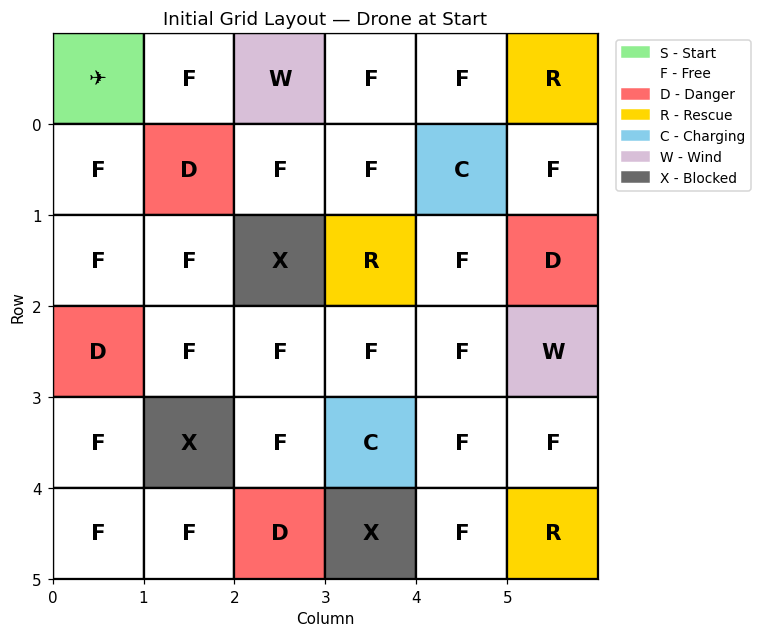

In [8]:
def plot_grid_colored(grid_layout, rescue_status=None, drone_pos=None, title='Drone Rescue Grid'):
    """
    Render the grid as a colored matplotlib figure with cell labels.
    
    Parameters
    ----------
    grid_layout : list of list of str
        The base grid layout.
    rescue_status : tuple or None
        Which rescues have been completed.
    drone_pos : tuple or None
        (row, col) of drone.
    title : str
        Plot title.
    """
    color_map = {
        'S': '#90EE90',   # light green
        'F': '#FFFFFF',   # white
        'D': '#FF6B6B',   # red
        'R': '#FFD700',   # gold
        'C': '#87CEEB',   # sky blue
        'W': '#D8BFD8',   # thistle / purple-ish
        'X': '#696969'    # dark gray
    }
    
    rows = len(grid_layout)
    cols = len(grid_layout[0])
    
    if rescue_status is None:
        rescue_status = tuple([0] * NUM_RESCUE_ACTUAL)
    
    fig, ax = plt.subplots(figsize=(cols + 1, rows + 1))
    
    rescue_idx = 0
    for r in range(rows):
        for c in range(cols):
            cell = grid_layout[r][c]
            display_cell = cell
            
            # Check if rescue target is already rescued
            if cell == 'R':
                loc_idx = RESCUE_POSITIONS.index((r, c))
                if rescue_status[loc_idx] == 1:
                    display_cell = 'F'
            
            bg_color = color_map.get(display_cell, '#FFFFFF')
            
            rect = plt.Rectangle((c, rows - 1 - r), 1, 1,
                                 facecolor=bg_color, edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
            
            label = display_cell
            if drone_pos and (r, c) == drone_pos:
                label = '✈'
            
            ax.text(c + 0.5, rows - 1 - r + 0.5, label,
                    ha='center', va='center', fontsize=14, fontweight='bold')
    
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.set_xticklabels(range(cols))
    ax.set_yticklabels(range(rows - 1, -1, -1))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_title(title)
    ax.set_aspect('equal')
    
    # Legend
    legend_items = [
        mpatches.Patch(color='#90EE90', label='S - Start'),
        mpatches.Patch(color='#FFFFFF', label='F - Free', edgecolor='black'),
        mpatches.Patch(color='#FF6B6B', label='D - Danger'),
        mpatches.Patch(color='#FFD700', label='R - Rescue'),
        mpatches.Patch(color='#87CEEB', label='C - Charging'),
        mpatches.Patch(color='#D8BFD8', label='W - Wind'),
        mpatches.Patch(color='#696969', label='X - Blocked')
    ]
    ax.legend(handles=legend_items, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    
    plt.tight_layout()
    plt.show()


plot_grid_colored(GRID_LAYOUT, drone_pos=START_POS, title='Initial Grid Layout — Drone at Start')

---
## Transition Dynamics Explanation

### Deterministic Transitions
When the drone is **not** on a wind cell, actions are fully deterministic:  
- Moving Up/Down/Left/Right shifts position by one cell in that direction.  
- If the target cell is out of bounds or blocked (X), the drone stays in place — but still loses 1 battery.

### Stochastic Wind Transitions
When the drone is on a **wind cell (W)** and takes a movement action:  
- With probability `WIND_PROB` (30%), the actual direction is replaced by a uniformly random direction (Up/Down/Left/Right).  
- With probability `1 - WIND_PROB` (70%), the intended direction is used.  
- Hover is not affected by wind.

### Battery
- Every action costs 1 battery unit.  
- Entering a charging station (C) refills battery to max.  
- Hovering on a charging station adds +2 but still costs 1, so net gain is +1 (capped at max).  
- Battery = 0 → episode terminates with -20 penalty.

### Rescue Logic
- Entering a rescue cell (R) that hasn't been rescued yet gives +20 reward and marks it as rescued.  
- The cell becomes a free cell (F) afterwards.  
- All rescues completed → episode ends.

### Danger Zones
- Entering a danger cell (D) gives -10 penalty.  
- The episode does **not** end — the drone can continue.

In [9]:
# Quick demo: show a few transitions from the start state
env_demo = DroneRescueEnv()
state = env_demo.reset()
print('=== Transition Examples ===')
print(f'Starting state: {state}')

demo_actions = [3, 3, 1, 1, 1, 3, 3]  # Right, Right, Down, Down, Down, Right, Right
for act in demo_actions:
    next_state, reward, done, info = env_demo.step(act)
    print(f'  Action: {ACTION_NAMES[act]:5s} -> State: {next_state}, Reward: {reward:+.0f}, Done: {done}, Info: {info}')
    if done:
        print('  Episode terminated.')
        break

=== Transition Examples ===
Starting state: (0, 0, 15, (0, 0, 0))
  Action: Right -> State: (0, 1, 14, (0, 0, 0)), Reward: -1, Done: False, Info: {'wind_hit': False, 'actual_action': 3, 'rescued_now': False, 'cell_type': 'F'}
  Action: Right -> State: (0, 2, 13, (0, 0, 0)), Reward: -1, Done: False, Info: {'wind_hit': False, 'actual_action': 3, 'rescued_now': False, 'cell_type': 'W'}
  Action: Down  -> State: (1, 2, 12, (0, 0, 0)), Reward: -1, Done: False, Info: {'wind_hit': False, 'actual_action': 1, 'rescued_now': False, 'cell_type': 'F'}
  Action: Down  -> State: (1, 2, 11, (0, 0, 0)), Reward: -1, Done: False, Info: {'wind_hit': False, 'actual_action': 1, 'rescued_now': False, 'cell_type': 'F'}
  Action: Down  -> State: (1, 2, 10, (0, 0, 0)), Reward: -1, Done: False, Info: {'wind_hit': False, 'actual_action': 1, 'rescued_now': False, 'cell_type': 'F'}
  Action: Right -> State: (1, 3, 9, (0, 0, 0)), Reward: -1, Done: False, Info: {'wind_hit': False, 'actual_action': 3, 'rescued_now': 

---
## Task 2 — Dynamic Programming: Value Iteration (2 Marks)

### State Representation

Each state is a tuple: `(row, col, battery, rescue_status_tuple)`  
- `row, col` ∈ {0..5} for a 6×6 grid (excluding blocked cells)  
- `battery` ∈ {0..MAX_BATTERY}  
- `rescue_status_tuple` ∈ all combinations of (0/1) for 3 rescue targets (8 combos, 7 non-terminal)  

Total states ≈ 33 valid positions × 15 battery levels × 7 rescue combos = 3465 (approx).

We enumerate all reachable non-terminal states and run the Bellman update until convergence.

In [10]:
def enumerate_all_states():
    """
    Generate all possible non-terminal states in the environment.
    
    A state is terminal if:
      - battery == 0
      - all rescues completed
    
    We exclude blocked cells from valid positions.
    
    Returns
    -------
    list of tuples
        Each tuple is (row, col, battery, rescue_status_tuple).
    """
    states = []
    
    # All valid (non-blocked) positions
    valid_positions = []
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            if (r, c) not in BLOCKED_POSITIONS:
                valid_positions.append((r, c))
    
    # All possible rescue status combinations
    rescue_combos = list(product([0, 1], repeat=NUM_RESCUE_ACTUAL))
    
    for (r, c) in valid_positions:
        for batt in range(1, MAX_BATTERY + 1):  # battery > 0 only
            for resc in rescue_combos:
                # Skip states where all rescues done (terminal)
                if all(x == 1 for x in resc):
                    continue
                states.append((r, c, batt, resc))
    
    return states, valid_positions


all_states, valid_pos_list = enumerate_all_states()
print(f'Total non-terminal states enumerated: {len(all_states)}')
print(f'Valid grid positions (excluding blocked): {len(valid_pos_list)}')
print(f'Rescue status combinations (non-terminal): {2**NUM_RESCUE_ACTUAL - 1}')
print(f'Battery levels: 1 to {MAX_BATTERY}')

Total non-terminal states enumerated: 3465
Valid grid positions (excluding blocked): 33
Rescue status combinations (non-terminal): 7
Battery levels: 1 to 15


In [11]:
def get_transitions(state, action, env_ref):
    """
    Compute all possible (probability, next_state, reward) outcomes
    for taking `action` in `state`.
    
    This handles stochastic wind transitions properly for value iteration.
    
    Parameters
    ----------
    state : tuple
        (row, col, battery, rescue_status_tuple).
    action : int
        Action index.
    env_ref : DroneRescueEnv
        Reference to environment (for helper methods).
    
    Returns
    -------
    list of (float, tuple, float)
        List of (probability, next_state, reward).
    """
    row, col, battery, rescue_tup = state
    transitions = []
    
    on_wind = (row, col) in env_ref.wind_locs
    is_movement = action in MOVEMENT_ACTIONS
    
    if on_wind and is_movement:
        # Stochastic: with WIND_PROB, direction is random
        # With (1 - WIND_PROB), intended direction is used
        action_probs = {}
        
        # Intended action happens with prob (1 - wind_prob) + wind_prob * 0.25
        # (because even under wind, 1/4 chance we get the intended direction)
        for wind_dir in MOVEMENT_ACTIONS:
            p = 0.0
            if wind_dir == action:
                p += (1.0 - WIND_PROB)  # no wind, intended direction
            p += WIND_PROB * 0.25  # wind blows in this direction
            
            if p > 0:
                if wind_dir in action_probs:
                    action_probs[wind_dir] += p
                else:
                    action_probs[wind_dir] = p
        
        for actual_action, prob in action_probs.items():
            ns, rew = _simulate_action_outcome(row, col, battery, rescue_tup, actual_action, env_ref)
            transitions.append((prob, ns, rew))
    else:
        # Deterministic transition
        ns, rew = _simulate_action_outcome(row, col, battery, rescue_tup, action, env_ref)
        transitions.append((1.0, ns, rew))
    
    return transitions


def _simulate_action_outcome(row, col, battery, rescue_tup, actual_action, env_ref):
    """
    Simulate the outcome of a specific action deterministically.
    
    Parameters
    ----------
    row, col : int
        Current position.
    battery : int
        Current battery.
    rescue_tup : tuple
        Rescue completion status.
    actual_action : int
        The action that actually executes.
    env_ref : DroneRescueEnv
        Environment reference.
    
    Returns
    -------
    tuple (state, reward)
        Next state and reward received.
    """
    # Compute new position
    if actual_action == 4:  # Hover
        new_r, new_c = row, col
    else:
        new_r, new_c = env_ref._compute_next_position(row, col, actual_action)
    
    actually_moved = (new_r, new_c) != (row, col)
    
    # Battery update
    if actual_action == 4 and (row, col) in env_ref.charge_locs:
        new_batt = min(battery + 2 - 1, env_ref.max_battery)  # hover on charger
    else:
        new_batt = battery - 1
    
    # Entering charging station (only when actually arriving from another cell)
    cell_type = env_ref.get_cell_type(new_r, new_c, rescue_tup)
    if cell_type == 'C' and actually_moved:
        new_batt = env_ref.max_battery
    
    # Rescue update
    new_rescue = list(rescue_tup)
    if cell_type == 'R':
        r_idx = env_ref.rescue_locs.index((new_r, new_c))
        if new_rescue[r_idx] == 0:
            new_rescue[r_idx] = 1
    new_rescue_tup = tuple(new_rescue)
    
    # Compute reward
    reward = REWARD_MOVE
    if new_batt <= 0:
        reward += REWARD_BATTERY_DEAD
    elif cell_type == 'R' and rescue_tup[env_ref.rescue_locs.index((new_r, new_c))] == 0:
        reward += REWARD_RESCUE
    elif cell_type == 'D':
        reward += REWARD_DANGER
    elif cell_type == 'C' and actually_moved:
        reward += REWARD_CHARGING
    
    next_state = (new_r, new_c, new_batt, new_rescue_tup)
    return next_state, reward


print('Transition functions defined.')

Transition functions defined.


In [12]:
def run_value_iteration(env_ref, gamma=GAMMA, threshold=CONVERGENCE_THRESHOLD):
    """
    Perform Value Iteration on the Drone Rescue MDP.
    
    Parameters
    ----------
    env_ref : DroneRescueEnv
        The environment instance.
    gamma : float
        Discount factor.
    threshold : float
        Convergence threshold (theta).
    
    Returns
    -------
    dict, dict, list
        V (value function), policy, convergence_log.
    """
    states_list, _ = enumerate_all_states()
    
    # Initialize value function to zero for all states
    V = {}
    for s in states_list:
        V[s] = 0.0
    
    convergence_log = []  # track (iteration, delta) pairs
    actions_available = [0, 1, 2, 3, 4]
    
    start_time = time.time()
    iteration = 0
    
    while True:
        delta = 0.0
        iteration += 1
        
        for s in states_list:
            old_v = V[s]
            
            # Find best action value
            best_val = float('-inf')
            
            for a in actions_available:
                transitions = get_transitions(s, a, env_ref)
                q_val = 0.0
                
                for (prob, ns, rew) in transitions:
                    nr, nc, nb, nresc = ns
                    
                    # Check if next state is terminal
                    is_terminal = (nb <= 0) or all(x == 1 for x in nresc)
                    
                    if is_terminal:
                        future_val = 0.0
                    else:
                        future_val = V.get(ns, 0.0)
                    
                    q_val += prob * (rew + gamma * future_val)
                
                if q_val > best_val:
                    best_val = q_val
            
            V[s] = best_val
            delta = max(delta, abs(old_v - best_val))
        
        convergence_log.append((iteration, delta))
        
        # Print progress periodically
        if iteration % 10 == 0 or delta < threshold:
            elapsed = time.time() - start_time
            print(f'  Iteration {iteration:4d} | delta = {delta:.6f} | time = {elapsed:.2f}s')
        
        if delta < threshold:
            break
        
        # Safety limit to prevent infinite loops
        if iteration > 500:
            print('  Warning: hit 500 iterations without converging.')
            break
    
    total_time = time.time() - start_time
    
    # --- Extract policy ---
    policy = {}
    for s in states_list:
        best_action = 4  # default to hover
        best_val = float('-inf')
        
        for a in actions_available:
            transitions = get_transitions(s, a, env_ref)
            q_val = 0.0
            
            for (prob, ns, rew) in transitions:
                nr, nc, nb, nresc = ns
                is_terminal = (nb <= 0) or all(x == 1 for x in nresc)
                future_val = 0.0 if is_terminal else V.get(ns, 0.0)
                q_val += prob * (rew + gamma * future_val)
            
            if q_val > best_val:
                best_val = q_val
                best_action = a
        
        policy[s] = best_action
    
    print(f'\nValue Iteration converged after {iteration} iterations.')
    print(f'Final delta: {delta:.6f}')
    print(f'Total runtime: {total_time:.2f} seconds')
    print(f'States processed per iteration: {len(states_list)}')
    
    return V, policy, convergence_log


print('Starting Value Iteration...\n')
env_vi = DroneRescueEnv()
V_star, optimal_policy, conv_log = run_value_iteration(env_vi)

Starting Value Iteration...

  Iteration   10 | delta = 6.202744 | time = 0.21s
  Iteration   20 | delta = 0.505779 | time = 0.42s
  Iteration   30 | delta = 0.181315 | time = 0.64s
  Iteration   40 | delta = 0.064999 | time = 0.86s
  Iteration   50 | delta = 0.023301 | time = 1.06s
  Iteration   60 | delta = 0.008353 | time = 1.28s
  Iteration   70 | delta = 0.002994 | time = 1.51s
  Iteration   80 | delta = 0.001073 | time = 1.70s
  Iteration   81 | delta = 0.000969 | time = 1.72s

Value Iteration converged after 81 iterations.
Final delta: 0.000969
Total runtime: 1.72 seconds
States processed per iteration: 3465


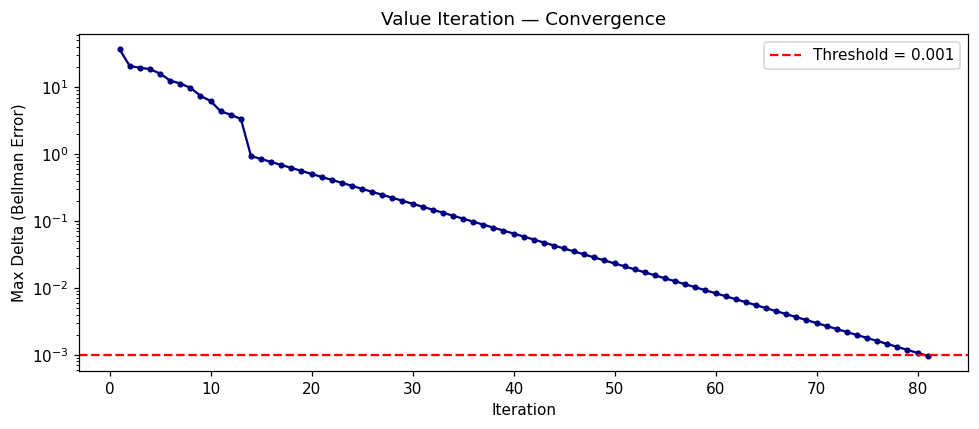

In [13]:
# Plot convergence curve
iters = [x[0] for x in conv_log]
deltas = [x[1] for x in conv_log]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(iters, deltas, color='navy', linewidth=1.5, marker='o', markersize=3)
ax.axhline(y=CONVERGENCE_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {CONVERGENCE_THRESHOLD}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Max Delta (Bellman Error)')
ax.set_title('Value Iteration — Convergence')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

---
## Task 3 — Policy Visualization (1 Mark)

We display the optimal policy as arrows on the grid for a specific battery level and rescue status.

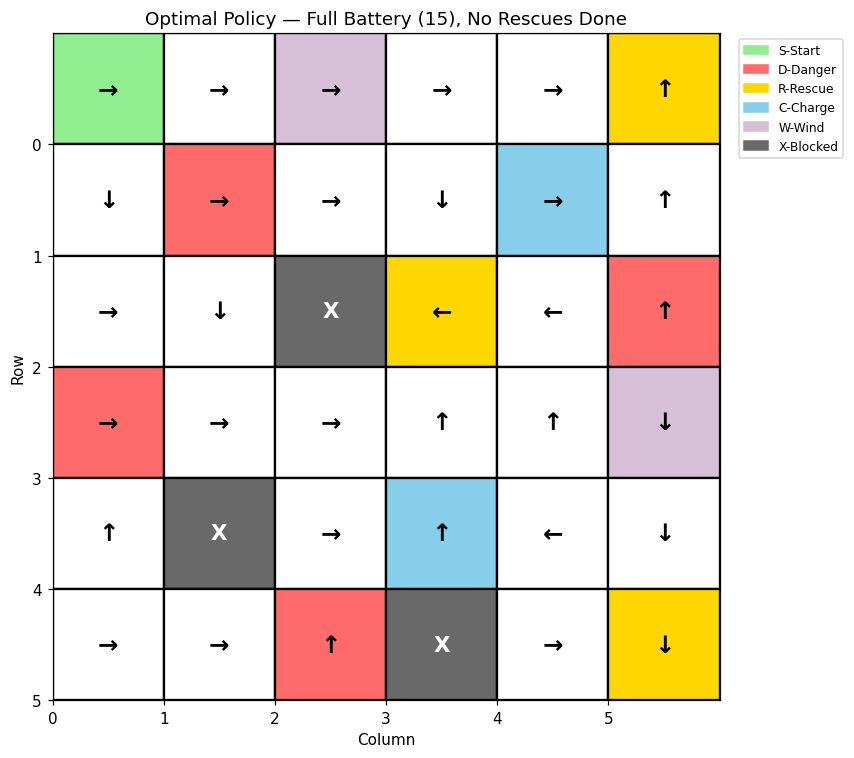

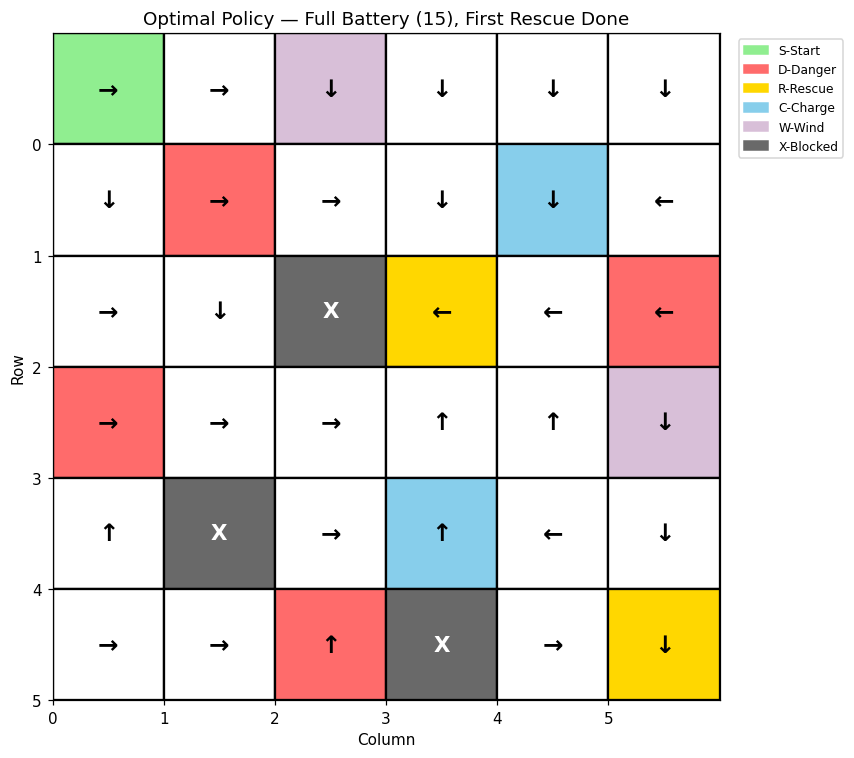

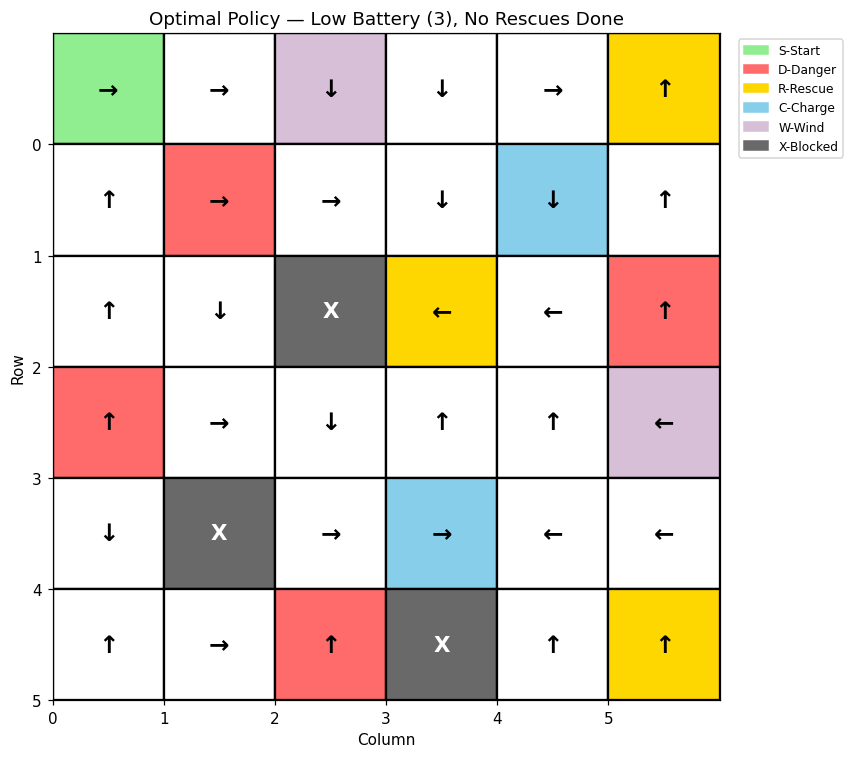

In [14]:
def show_policy_grid(policy, battery_level, rescue_status, title=None):
    """
    Display the optimal policy as arrows on the grid.
    
    Parameters
    ----------
    policy : dict
        state -> action mapping.
    battery_level : int
        Battery level slice to display.
    rescue_status : tuple
        Rescue status slice to display.
    title : str or None
        Plot title.
    """
    if title is None:
        title = f'Policy (battery={battery_level}, rescued={rescue_status})'
    
    color_map = {
        'S': '#90EE90', 'F': '#FFFFFF', 'D': '#FF6B6B',
        'R': '#FFD700', 'C': '#87CEEB', 'W': '#D8BFD8', 'X': '#696969'
    }
    
    fig, ax = plt.subplots(figsize=(GRID_COLS + 2, GRID_ROWS + 1))
    
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            # Determine cell type
            cell = GRID_LAYOUT[r][c]
            if cell == 'R':
                r_idx = RESCUE_POSITIONS.index((r, c))
                if rescue_status[r_idx] == 1:
                    cell = 'F'
            
            bg = color_map.get(cell, '#FFFFFF')
            rect = plt.Rectangle((c, GRID_ROWS - 1 - r), 1, 1,
                                 facecolor=bg, edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
            
            if cell == 'X':
                ax.text(c + 0.5, GRID_ROWS - 1 - r + 0.5, 'X',
                        ha='center', va='center', fontsize=14, color='white', fontweight='bold')
                continue
            
            state = (r, c, battery_level, rescue_status)
            if state in policy:
                action = policy[state]
                symbol = ARROW_SYMBOLS[action]
                ax.text(c + 0.5, GRID_ROWS - 1 - r + 0.5, symbol,
                        ha='center', va='center', fontsize=16, fontweight='bold')
            else:
                ax.text(c + 0.5, GRID_ROWS - 1 - r + 0.5, '·',
                        ha='center', va='center', fontsize=14, color='gray')
    
    ax.set_xlim(0, GRID_COLS)
    ax.set_ylim(0, GRID_ROWS)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_xticklabels(range(GRID_COLS))
    ax.set_yticklabels(range(GRID_ROWS - 1, -1, -1))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_title(title)
    ax.set_aspect('equal')
    
    legend_items = [
        mpatches.Patch(color='#90EE90', label='S-Start'),
        mpatches.Patch(color='#FF6B6B', label='D-Danger'),
        mpatches.Patch(color='#FFD700', label='R-Rescue'),
        mpatches.Patch(color='#87CEEB', label='C-Charge'),
        mpatches.Patch(color='#D8BFD8', label='W-Wind'),
        mpatches.Patch(color='#696969', label='X-Blocked')
    ]
    ax.legend(handles=legend_items, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
    plt.tight_layout()
    plt.show()


# Use tuples matching NUM_RESCUE_ACTUAL (3 rescue targets for group ending 5)
no_rescues = tuple([0] * NUM_RESCUE_ACTUAL)
first_rescued = tuple([1] + [0] * (NUM_RESCUE_ACTUAL - 1))

# Show policy at full battery, no rescues done
show_policy_grid(optimal_policy, MAX_BATTERY, no_rescues,
                 title=f'Optimal Policy — Full Battery ({MAX_BATTERY}), No Rescues Done')

# Show policy at full battery, first rescue done
show_policy_grid(optimal_policy, MAX_BATTERY, first_rescued,
                 title=f'Optimal Policy — Full Battery ({MAX_BATTERY}), First Rescue Done')

# Show policy at low battery, no rescues done
show_policy_grid(optimal_policy, 3, no_rescues,
                 title='Optimal Policy — Low Battery (3), No Rescues Done')

### Policy Interpretation

- At full battery with no rescues done, the drone heads toward the nearest rescue target.  
- After completing the first rescue, the policy directs the drone toward the second target, possibly detouring through the charging station if battery is getting low.  
- At very low battery, the policy should steer the drone toward the charging station or hover on it — since running out of battery incurs a -20 penalty, self-preservation takes priority over rescue attempts.

---
## Task 4 — State-Value Analysis (1 Mark)

We fix the rescue status and battery level, then plot how the value function V*(s) varies
across different drone positions. This gives a spatial heatmap showing which grid positions
are "most valuable" to be in.

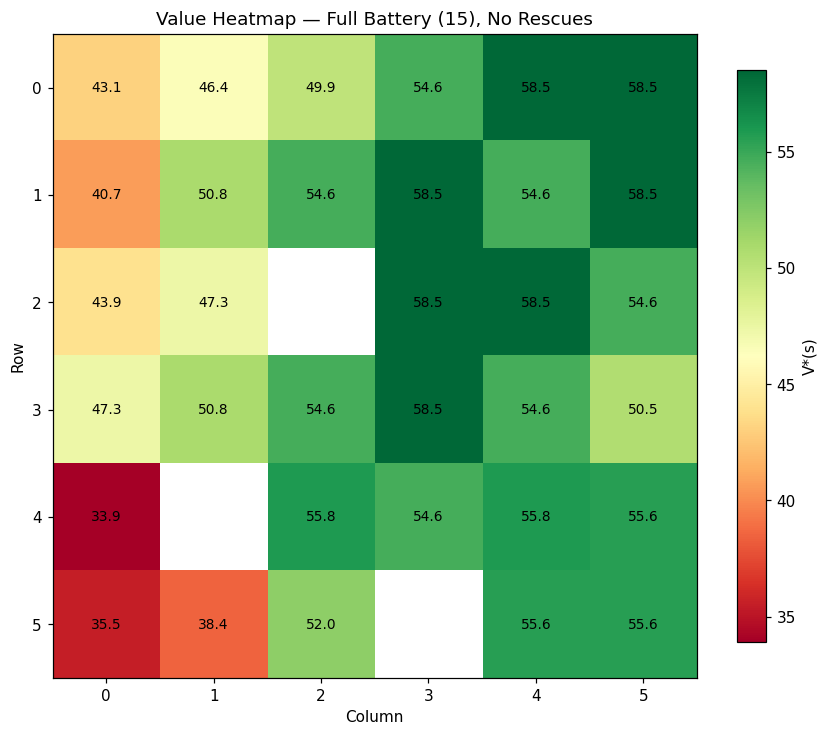

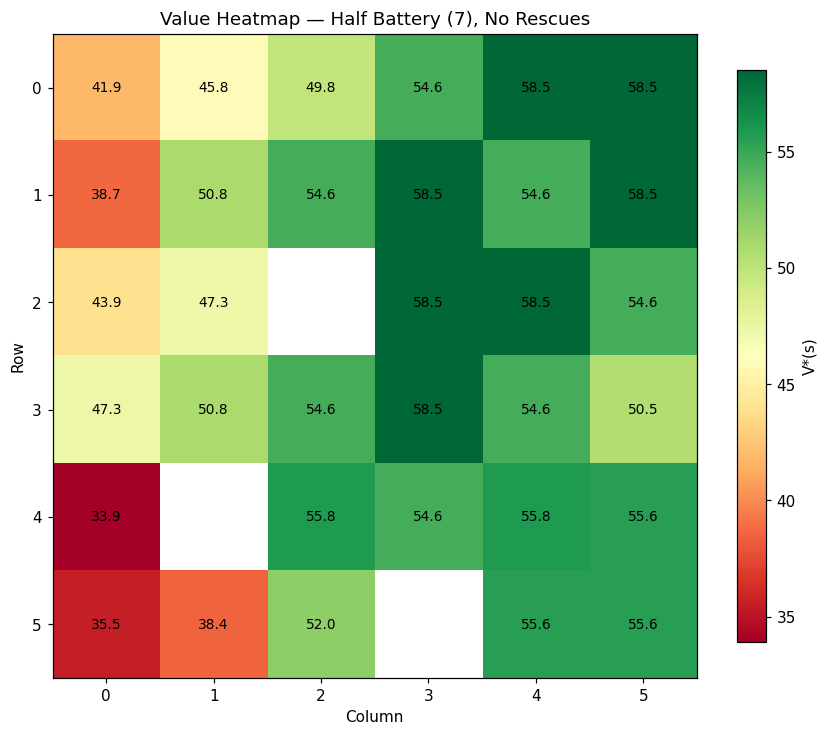

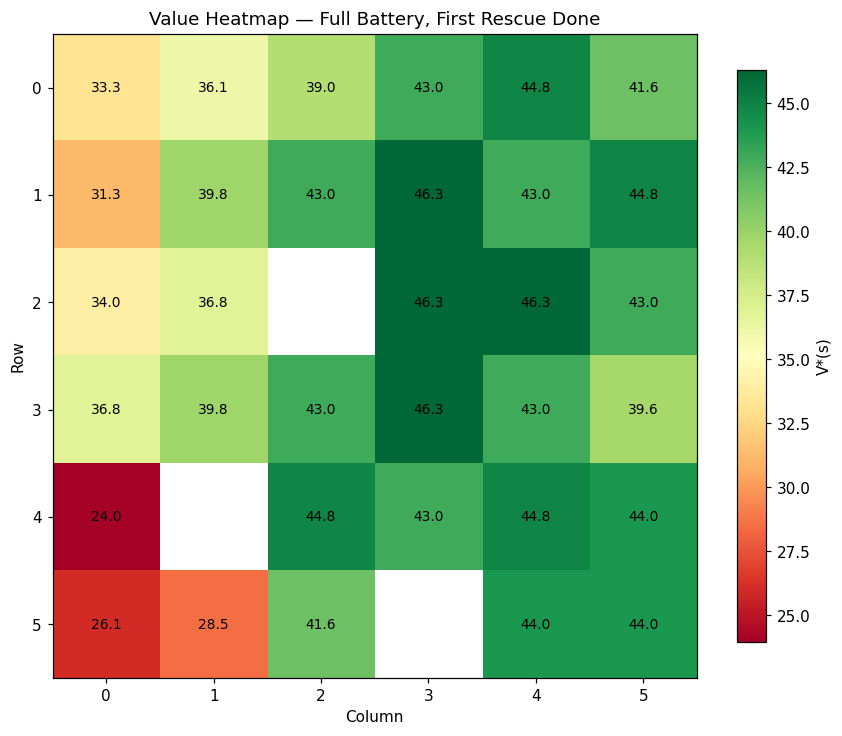

In [15]:
def plot_value_heatmap(V, battery_level, rescue_status, title=None):
    """
    Plot a heatmap of V*(s) over all grid positions for a fixed battery and rescue status.
    
    Parameters
    ----------
    V : dict
        Value function mapping states to values.
    battery_level : int
        Fixed battery for the slice.
    rescue_status : tuple
        Fixed rescue status.
    title : str or None
        Plot title.
    """
    if title is None:
        title = f'V*(s) Heatmap — Battery={battery_level}, Rescued={rescue_status}'
    
    val_grid = np.full((GRID_ROWS, GRID_COLS), np.nan)
    
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            if (r, c) in BLOCKED_POSITIONS:
                continue
            state = (r, c, battery_level, rescue_status)
            if state in V:
                val_grid[r][c] = V[state]
    
    fig, ax = plt.subplots(figsize=(GRID_COLS + 2, GRID_ROWS + 1))
    
    # Mask NaN values for blocked cells
    masked_grid = np.ma.masked_invalid(val_grid)
    
    cmap = plt.cm.RdYlGn  # red=low, green=high
    im = ax.imshow(masked_grid, cmap=cmap, interpolation='nearest', origin='upper')
    
    # Annotate each cell with its value
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            if (r, c) in BLOCKED_POSITIONS:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
            elif not np.isnan(val_grid[r][c]):
                ax.text(c, r, f'{val_grid[r][c]:.1f}', ha='center', va='center', fontsize=9)
    
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8, label='V*(s)')
    plt.tight_layout()
    plt.show()


# Use tuples matching NUM_RESCUE_ACTUAL (3 rescue targets for group ending 5)
no_rescues = tuple([0] * NUM_RESCUE_ACTUAL)
first_rescued = tuple([1] + [0] * (NUM_RESCUE_ACTUAL - 1))

# Heatmap 1: full battery, no rescues done
plot_value_heatmap(V_star, MAX_BATTERY, no_rescues,
                   title=f'Value Heatmap — Full Battery ({MAX_BATTERY}), No Rescues')

# Heatmap 2: half battery, no rescues
plot_value_heatmap(V_star, MAX_BATTERY // 2, no_rescues,
                   title=f'Value Heatmap — Half Battery ({MAX_BATTERY // 2}), No Rescues')

# Heatmap 3: full battery, first rescue done
plot_value_heatmap(V_star, MAX_BATTERY, first_rescued,
                   title=f'Value Heatmap — Full Battery, First Rescue Done')

### Value Function Interpretation

- **High-value regions** appear near rescue targets (since reaching them gives +20 reward) and near the charging station (which enables the drone to extend its operational time).

- **Low-value regions** appear near danger zones (D), which penalize the drone with -10 upon entry. The cells adjacent to danger zones also tend to have reduced values because of the risk of accidentally entering them.

- The **charging station** acts as a "value booster" — cells near it have higher values because the drone can refuel and continue rescuing. At low battery, this effect becomes even more pronounced since battery death carries a -20 penalty.

- When the **first rescue is completed**, the value landscape shifts: previously high-value cells near the first rescue target lose their advantage, and the remaining rescue target becomes the primary attractor.

- At **lower battery levels**, overall values decrease because the drone has fewer steps available, making it harder to reach rescue targets and more likely to run out of power.

---
## Episode Simulation — Running the Optimal Policy

We simulate one complete episode following the computed optimal policy.

In [16]:
def simulate_episode(env, policy, verbose=True):
    """
    Run a full episode using the given policy.
    
    Parameters
    ----------
    env : DroneRescueEnv
        The environment.
    policy : dict
        State -> action mapping.
    verbose : bool
        Whether to print step-by-step details.
    
    Returns
    -------
    dict
        Episode summary: total_reward, steps, trajectory, etc.
    """
    np.random.seed(42)  # fixed seed for reproducible simulation
    
    state = env.reset()
    total_reward = 0.0
    trajectory = [state]
    step_log = []
    
    if verbose:
        print('=== Episode Simulation with Optimal Policy ===')
        print(f'Initial state: {state}\n')
    
    while not env.done:
        if state in policy:
            action = policy[state]
        else:
            # State not in policy (terminal or unvisited) — default hover
            action = 4
        
        next_state, reward, done, info = env.step(action)
        total_reward += reward
        
        step_info = {
            'step': env.step_count,
            'state_before': state,
            'action': ACTION_NAMES[action],
            'actual_action': ACTION_NAMES[info['actual_action']],
            'reward': reward,
            'new_state': next_state,
            'wind_hit': info['wind_hit'],
            'rescued': info['rescued_now']
        }
        step_log.append(step_info)
        
        if verbose:
            wind_tag = ' [WIND!]' if info['wind_hit'] else ''
            rescue_tag = ' ** RESCUED! **' if info['rescued_now'] else ''
            r, c, b, resc = next_state
            print(f'  Step {env.step_count:2d}: Action={ACTION_NAMES[action]:5s}{wind_tag} '
                  f'-> Pos=({r},{c}) Batt={b:2d} Rescue={resc} '
                  f'Reward={reward:+.0f}{rescue_tag}')
        
        trajectory.append(next_state)
        state = next_state
    
    if verbose:
        print(f'\n--- Episode Summary ---')
        print(f'Total reward     : {total_reward:.1f}')
        print(f'Total steps      : {env.step_count}')
        print(f'Final battery    : {state[2]}')
        print(f'Rescues completed: {list(state[3])}')
        all_done = all(x == 1 for x in state[3])
        print(f'All rescued?     : {"Yes" if all_done else "No"}')
    
    return {
        'total_reward': total_reward,
        'steps': env.step_count,
        'trajectory': trajectory,
        'step_log': step_log,
        'final_state': state
    }


env_sim = DroneRescueEnv()
episode_result = simulate_episode(env_sim, optimal_policy, verbose=True)

=== Episode Simulation with Optimal Policy ===
Initial state: (0, 0, 15, (0, 0, 0))

  Step  1: Action=Right -> Pos=(0,1) Batt=14 Rescue=(0, 0, 0) Reward=-1
  Step  2: Action=Right -> Pos=(0,2) Batt=13 Rescue=(0, 0, 0) Reward=-1
  Step  3: Action=Right -> Pos=(0,3) Batt=12 Rescue=(0, 0, 0) Reward=-1
  Step  4: Action=Right -> Pos=(0,4) Batt=11 Rescue=(0, 0, 0) Reward=-1
  Step  5: Action=Right -> Pos=(0,5) Batt=10 Rescue=(1, 0, 0) Reward=+19 ** RESCUED! **
  Step  6: Action=Down  -> Pos=(1,5) Batt= 9 Rescue=(1, 0, 0) Reward=-1
  Step  7: Action=Left  -> Pos=(1,4) Batt=15 Rescue=(1, 0, 0) Reward=+4
  Step  8: Action=Down  -> Pos=(2,4) Batt=14 Rescue=(1, 0, 0) Reward=-1
  Step  9: Action=Left  -> Pos=(2,3) Batt=13 Rescue=(1, 1, 0) Reward=+19 ** RESCUED! **
  Step 10: Action=Down  -> Pos=(3,3) Batt=12 Rescue=(1, 1, 0) Reward=-1
  Step 11: Action=Down  -> Pos=(4,3) Batt=15 Rescue=(1, 1, 0) Reward=+4
  Step 12: Action=Right -> Pos=(4,4) Batt=14 Rescue=(1, 1, 0) Reward=-1
  Step 13: Action=L

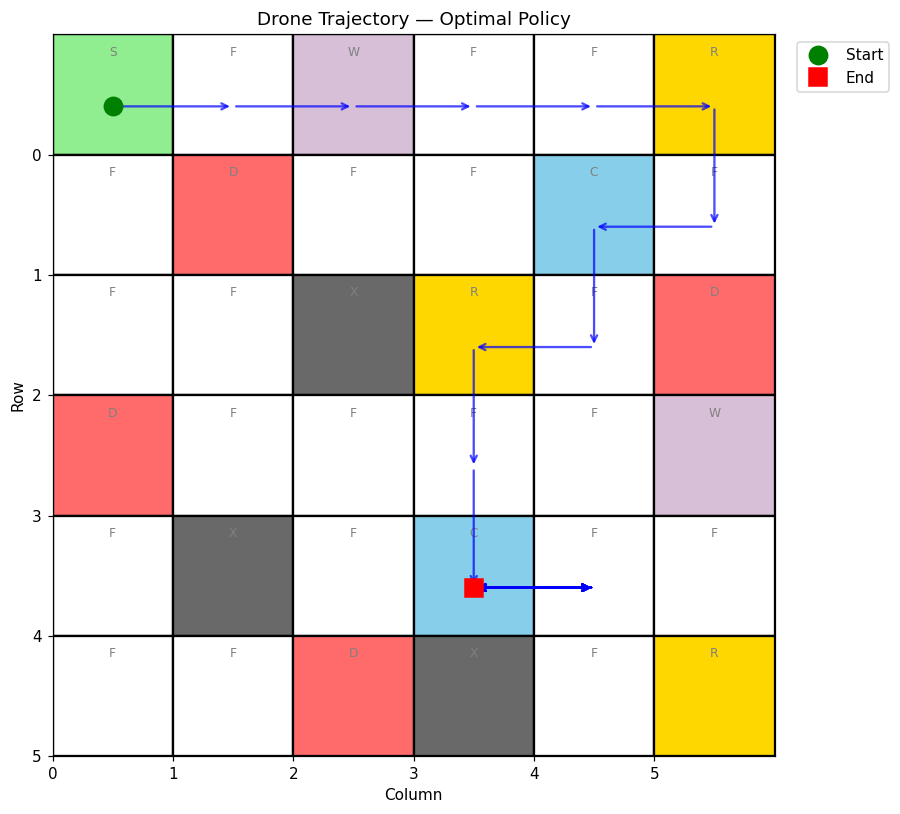

In [17]:
# Visualize the trajectory on the grid
def plot_trajectory(trajectory, title='Drone Trajectory — Optimal Policy'):
    """
    Draw the drone's path overlaid on the grid.
    
    Parameters
    ----------
    trajectory : list of tuples
        Sequence of (row, col, battery, rescue) states.
    title : str
        Plot title.
    """
    color_map = {
        'S': '#90EE90', 'F': '#FFFFFF', 'D': '#FF6B6B',
        'R': '#FFD700', 'C': '#87CEEB', 'W': '#D8BFD8', 'X': '#696969'
    }
    
    fig, ax = plt.subplots(figsize=(GRID_COLS + 2, GRID_ROWS + 1.5))
    
    # Draw grid
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cell = GRID_LAYOUT[r][c]
            bg = color_map.get(cell, '#FFFFFF')
            rect = plt.Rectangle((c, GRID_ROWS - 1 - r), 1, 1,
                                 facecolor=bg, edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(c + 0.5, GRID_ROWS - 1 - r + 0.85, cell,
                    ha='center', va='center', fontsize=8, color='gray')
    
    # Draw trajectory path
    positions = [(s[1] + 0.5, GRID_ROWS - 1 - s[0] + 0.4) for s in trajectory]
    
    for i in range(len(positions) - 1):
        x0, y0 = positions[i]
        x1, y1 = positions[i + 1]
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))
    
    # Mark start and end
    ax.plot(positions[0][0], positions[0][1], 'go', markersize=12, label='Start', zorder=5)
    ax.plot(positions[-1][0], positions[-1][1], 'rs', markersize=12, label='End', zorder=5)
    
    ax.set_xlim(0, GRID_COLS)
    ax.set_ylim(0, GRID_ROWS)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_xticklabels(range(GRID_COLS))
    ax.set_yticklabels(range(GRID_ROWS - 1, -1, -1))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()


plot_trajectory(episode_result['trajectory'])

---
## Task 5 — DP Scalability Discussion (1 Mark)

### Curse of Dimensionality

In our current 6×6 grid with 3 rescue targets and battery capacity 15, the state space is manageable: roughly 33 valid positions × 15 battery levels × 7 rescue combinations ≈ 3465 non-terminal states. Value iteration converges in reasonable time because we can enumerate and update every state.

But this breaks down quickly when we scale up:

**Larger grids (e.g. 10×10):**  
Moving from a 6×6 to a 10×10 grid roughly triples the number of positions from ~33 to ~100. If we also increase battery capacity proportionally, the state space grows multiplicatively. With 100 positions × 20 battery levels × rescue combinations, we could easily reach tens of thousands of states — still technically feasible, but noticeably slower.

**More rescue targets:**  
This is where things really explode. Each rescue target doubles the rescue status combinations (it's a binary tuple). With 2 targets we have 4 combinations, with 5 targets we have 32, with 10 targets we'd have 1024. Combined with position and battery dimensions, this exponential growth makes tabular methods impractical. For example, a 10×10 grid with 10 rescue targets and battery=20 gives roughly 100 × 20 × 1024 ≈ 2 million states.

**Dynamic weather / changing conditions:**  
If wind patterns change over time (e.g. wind zones shift every N steps), we need to encode the current weather state as part of the MDP state. This adds another dimension to an already large state space. If there are multiple possible weather configurations, the state space multiplies by that factor.

### Why DP Becomes Difficult

Value iteration (and policy iteration) require iterating over **every state** in every sweep. As the state space grows exponentially:
- Memory to store V(s) becomes prohibitive
- Each iteration takes much longer
- More iterations may be needed if the state space has long "corridors" where value propagates slowly
- Building the transition model itself becomes expensive to enumerate

### How Deep RL Helps

Deep RL methods (like DQN, PPO, A3C) address these issues by:
1. **Function approximation:** Instead of storing V(s) for every state, a neural network approximates V(s) or Q(s,a). This scales to enormous state spaces because the network generalizes across similar states.
2. **Sample-based learning:** Deep RL doesn't need to enumerate all states — it learns from sampled trajectories. This is especially valuable when most states are rarely visited.
3. **Handling continuous states:** If we model battery as continuous or add GPS coordinates, tabular DP can't handle it, but neural networks can naturally process continuous inputs.

### Connection to Real-World Autonomous Drones

Real autonomous rescue drones face challenges far beyond our grid world:
- Continuous 3D position space (latitude, longitude, altitude)
- Dynamic obstacles (moving debris, other drones)
- Communication constraints and partial observability
- Variable weather affecting flight dynamics in real-time
- Multiple objectives simultaneously (rescue, survey, deliver supplies)

For these scenarios, deep RL combined with sensor fusion and sim-to-real transfer learning is the practical approach. Companies working on autonomous drone navigation (like Skydio) use learned policies trained in simulation and transferred to real hardware. Our DP solution here serves as a foundational understanding of the underlying MDP framework, but any practical deployment would require the scalability that deep learning provides.

---
## Final Conclusions — Part 2 (Dynamic Programming)

- We designed and implemented a custom Drone Rescue MDP environment from scratch, handling battery mechanics, wind stochasticity, rescue logic, danger penalties, and blocked cells.
- Value Iteration was used to compute the optimal value function V*(s) and the corresponding optimal policy π*(s) over the full state space.
- The policy correctly prioritizes rescue targets while avoiding danger zones and managing battery constraints — at low battery, the drone heads toward the charging station instead of risking battery death.
- Value heatmaps reveal the spatial structure of the problem: high values near rescue targets and the charging station, low values near danger zones.
- The scalability analysis shows that while DP works well for small grid worlds, real-world applications require deep RL methods to handle the exponential growth of state spaces.

---
*End of Part 2 — Dynamic Programming*